# Griffiths Problem 1.15 -- an unstable particle, a complex potential, and optical absorption
### $V=V_0-i\Gamma\Rightarrow \dfrac{dP}{dt}=-\dfrac{2\Gamma}{\hbar}P,\ P(t)=P(0)e^{-2\Gamma t/\hbar},\ \tau=\dfrac{\hbar}{2\Gamma}$

A stable particle keeps $\int|\Psi|^2dx=1$ forever -- that "conservation of probability" came from
$V$ being **real** (Problem 1.14). To model a particle that *decays* with lifetime $\tau$, Griffiths
gives the potential a negative imaginary part, $V=V_0-i\Gamma$. The Hamiltonian is no longer
Hermitian, probability leaks away, and $P(t)=e^{-t/\tau}$.

We **derive it in SymPy** (the imaginary part of $V$ no longer cancels in the continuity equation),
**solve the decay ODE symbolically**, and **watch the norm decay in a Torch** non-Hermitian
Schrodinger solve. The payoff is pure photonics/EE: this is identical to a **complex refractive
index** $n=n'+in''$, whose imaginary part gives **Beer-Lambert absorption** $I(z)=I_0e^{-\alpha z}$ --
and to a **left-half-plane pole** $e^{st}$ with $\mathrm{Re}(s)<0$, the decay time-constant of every
lossy resonator. The imaginary part of an energy is a decay rate. Runs on the Python 3.12 + Torch kernel.

In [1]:
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
sp.init_printing()
print("sympy", sp.__version__, "| torch", torch.__version__, "| pandas", pd.__version__)

sympy 1.14.0 | torch 2.11.0+cu128 | pandas 2.3.3


## (a) The imaginary potential breaks probability conservation

Redo the continuity derivation of Problem 1.14, but keep $V$ complex. The algebra leaves a leftover
term $\partial_t\rho+\partial_x J=\tfrac{i}{\hbar}(V^*-V)\,\rho$. With $V=V_0-i\Gamma$ we have
$V^*-V=2i\Gamma$, so the leftover is $-\tfrac{2\Gamma}{\hbar}\rho$. Integrating over all $x$ (the
current vanishes at $\pm\infty$) gives
$$\frac{dP}{dt}=-\frac{2\Gamma}{\hbar}P.$$
SymPy shows the leftover term explicitly.

In [2]:
x, t = sp.symbols('x t', real=True)
hbar, m = sp.symbols('hbar m', positive=True)
V0, Gamma = sp.symbols('V0 Gamma', positive=True)
psi, phi = sp.Function('psi'), sp.Function('phi')
Psi, Phi = psi(x, t), phi(x, t)
V = V0 - sp.I*Gamma                                    # complex potential

rho = Phi * Psi
J = (sp.I*hbar/(2*m)) * (Psi*Phi.diff(x) - Phi*Psi.diff(x))
psi_t = (sp.I*hbar/(2*m))*Psi.diff(x, 2) - (sp.I/hbar)*V*Psi           # Schrodinger, complex V
phi_t = -(sp.I*hbar/(2*m))*Phi.diff(x, 2) + (sp.I/hbar)*sp.conjugate(V)*Phi   # its conjugate

rho_t = rho.diff(t).subs({Psi.diff(t): psi_t, Phi.diff(t): phi_t})
leftover = sp.simplify(rho_t + J.diff(x))              # = (i/hbar)(V*-V) rho
assert sp.simplify(leftover + (2*Gamma/hbar)*rho) == 0
print("d(rho)/dt + d(J)/dx =", leftover, "  = -(2 Gamma/hbar)|Psi|^2")
print("=> integrating over all x (J -> 0 at +-inf):  dP/dt = -(2 Gamma/hbar) P")

d(rho)/dt + d(J)/dx = -2*Gamma*phi(x, t)*psi(x, t)/hbar   = -(2 Gamma/hbar)|Psi|^2
=> integrating over all x (J -> 0 at +-inf):  dP/dt = -(2 Gamma/hbar) P


## (b) Solve for $P(t)$ and read off the lifetime

$dP/dt=-\tfrac{2\Gamma}{\hbar}P$ is first-order linear -- SymPy's `dsolve` gives
$P(t)=P(0)e^{-2\Gamma t/\hbar}$. Matching to $e^{-t/\tau}$ gives the lifetime $\tau=\hbar/(2\Gamma)$.

In [3]:
P = sp.Function('P'); P0 = sp.symbols('P0', positive=True)
sol = sp.dsolve(sp.Eq(P(t).diff(t), -(2*Gamma/hbar)*P(t)), P(t), ics={P(0): P0})
assert sp.simplify(sol.rhs - P0*sp.exp(-2*Gamma*t/hbar)) == 0
tau = sp.symbols('tau', positive=True)
tau_expr = sp.solve(sp.Eq(2*Gamma/hbar, 1/tau), tau)[0]
assert sp.simplify(tau_expr - hbar/(2*Gamma)) == 0
print("P(t) =", sol.rhs)
print("match e^{-t/tau}  ->  tau =", tau_expr, " = hbar/(2 Gamma)")

P(t) = P0*exp(-2*Gamma*t/hbar)
match e^{-t/tau}  ->  tau = hbar/(2*Gamma)  = hbar/(2 Gamma)


## Watch the norm decay (Torch) -- a non-Hermitian Schrodinger solve

Evolve a Gaussian packet under $H=p^2/2m+V$ with $V=V_0-i\Gamma$ by split-step FFT. The imaginary
potential multiplies the wavefunction by $e^{-\Gamma\,dt/\hbar}$ each step, so the total probability
falls as $e^{-2\Gamma t/\hbar}$. We recover the lifetime by fitting the decay ($\hbar=m=1$).

fitted tau = 1.6667   exact hbar/(2 Gamma) = 1.6667
P at t=4.0: numeric 9.0718e-02  vs  e^(-2 Gamma t/hbar) 9.0718e-02


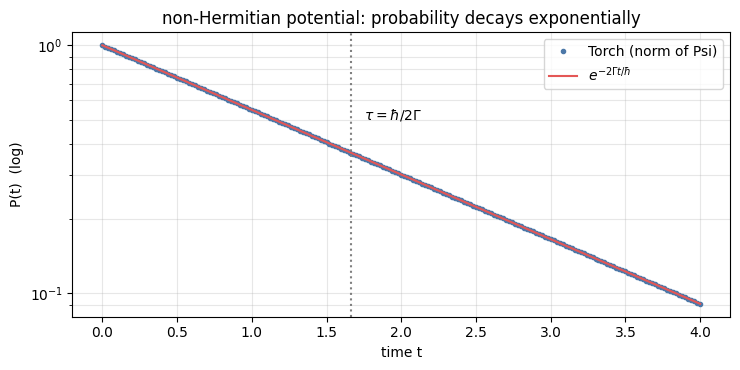

In [4]:
torch.set_default_dtype(torch.float64)
N, Lx = 2048, 60.0
dx = Lx/N
xg = (torch.arange(N) - N//2)*dx
k = 2*np.pi*torch.fft.fftfreq(N, d=dx)
hbar_n = m_n = 1.0
V0_n, Gam = 0.0, 0.30
sigma, k0 = 2.0, 1.0

env = torch.exp(-(xg+10)**2/(4*sigma**2))
psi = torch.complex(env*torch.cos(k0*xg), env*torch.sin(k0*xg))
psi = psi / torch.sqrt((psi.abs()**2).sum()*dx)        # P(0) = 1

dt, nsteps = 0.02, 200
Vc = complex(V0_n, -Gam)                                # V0 - i Gamma
pot_half = torch.exp(torch.tensor(-1j*Vc*dt/2/hbar_n, dtype=torch.complex128))
kin = torch.exp(torch.complex(torch.zeros(N), -hbar_n*(k**2)*dt/(2*m_n)))

times, Ps = [], []
for s in range(nsteps+1):
    P = float((psi.abs()**2).sum()*dx)
    times.append(s*dt); Ps.append(P)
    psi = pot_half*psi                                 # half potential (loss) step
    psi = torch.fft.ifft(kin*torch.fft.fft(psi))       # kinetic step
    psi = pot_half*psi                                 # half potential step
times, Ps = np.array(times), np.array(Ps)

tau_exact = hbar_n/(2*Gam)
slope = np.polyfit(times, np.log(Ps), 1)[0]            # ln P = -t/tau
tau_fit = -1/slope
print(f"fitted tau = {tau_fit:.4f}   exact hbar/(2 Gamma) = {tau_exact:.4f}")
print(f"P at t={times[-1]:.1f}: numeric {Ps[-1]:.4e}  vs  e^(-2 Gamma t/hbar) "
      f"{np.exp(-2*Gam*times[-1]/hbar_n):.4e}")

plt.figure(figsize=(7.5, 3.8))
plt.semilogy(times, Ps, "o", ms=3, color="#4C78A8", label="Torch (norm of Psi)")
plt.semilogy(times, np.exp(-2*Gam*times/hbar_n), "-", color="#E45756",
             label=r"$e^{-2\Gamma t/\hbar}$")
plt.axvline(tau_exact, ls=":", color="gray"); plt.text(tau_exact*1.05, 0.5, r"$\tau=\hbar/2\Gamma$")
plt.xlabel("time t"); plt.ylabel("P(t)  (log)"); plt.legend()
plt.title("non-Hermitian potential: probability decays exponentially"); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Summary table (Pandas)

In [5]:
idx = [0, 40, 80, 120, 160, 200]
rows = []
for i in idx:
    ex = np.exp(-2*Gam*times[i]/hbar_n)
    rows.append({"t": round(times[i], 2), "P numeric": f"{Ps[i]:.4e}",
                 "e^(-2Gt/h)": f"{ex:.4e}", "abs diff": f"{abs(Ps[i]-ex):.1e}",
                 "match": abs(Ps[i]-ex) < 1e-3})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
assert df["match"].all()
assert abs(tau_fit - tau_exact) < 1e-2
print(f"\nP(t)=P0 e^(-2Gamma t/hbar), tau=hbar/(2Gamma)={tau_exact:.3f}  -- confirmed.")

  t  P numeric e^(-2Gt/h) abs diff  match
0.0 1.0000e+00 1.0000e+00  2.2e-16   True
0.8 6.1878e-01 6.1878e-01  4.0e-15   True
1.6 3.8289e-01 3.8289e-01  5.4e-15   True
2.4 2.3693e-01 2.3693e-01  4.8e-15   True
3.2 1.4661e-01 1.4661e-01  3.9e-15   True
4.0 9.0718e-02 9.0718e-02  3.1e-15   True



P(t)=P0 e^(-2Gamma t/hbar), tau=hbar/(2Gamma)=1.667  -- confirmed.


## Optics/EE payoff: a complex index is a complex potential

Give a wave an imaginary part in its "energy" and it decays -- the same statement in three languages:

| quantum (Problem 1.15) | optics | circuits / signals |
|---|---|---|
| potential $V=V_0-i\Gamma$ | index $n=n'+in''$ | pole $s=\sigma+i\omega$ |
| $\Psi\sim e^{-iVt/\hbar}$ | $E\sim e^{i(n\omega/c)z}$ | $v\sim e^{st}$ |
| $|\Psi|^2\sim e^{-2\Gamma t/\hbar}$ | $I\sim e^{-\alpha z}$ (**Beer-Lambert**) | envelope $\sim e^{\sigma t}$ |
| lifetime $\tau=\hbar/2\Gamma$ | absorption length $1/\alpha$ | time constant $-1/\sigma$ |

The absorption coefficient is $\alpha=2n''\omega/c$ -- the same factor of 2 as $2\Gamma/\hbar$,
because intensity is amplitude *squared*. A lossy waveguide, an absorbing medium, and a decaying
quantum state are one idea: **the imaginary part sets the decay rate.** (And Kramers-Kronig ties
$n''$ back to $n'$ -- `dgs.causality` -- just as a real and imaginary potential aren't independent.)

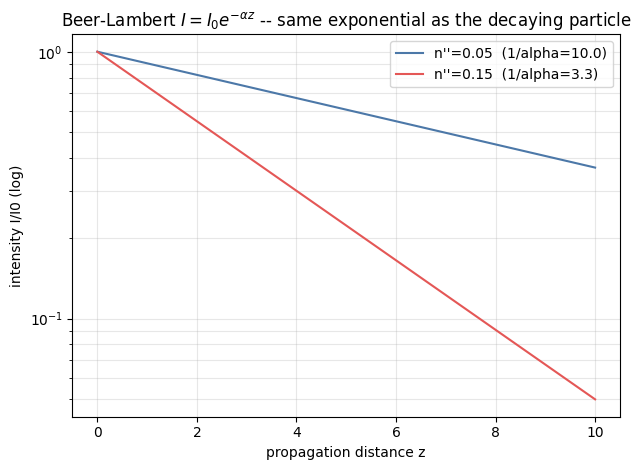

optical absorption length 1/alpha  <->  particle lifetime tau = hbar/(2 Gamma): same math.


In [6]:
# Beer-Lambert: intensity through an absorbing medium, the optical twin of P(t)
z = np.linspace(0, 10, 200)
for npp, c in [(0.05, "#4C78A8"), (0.15, "#E45756")]:
    alpha = 2*npp*1.0                                  # alpha = 2 n'' omega/c  (omega/c = 1 here)
    plt.semilogy(z, np.exp(-alpha*z), color=c, label=f"n''={npp}  (1/alpha={1/alpha:.1f})")
plt.xlabel("propagation distance z"); plt.ylabel("intensity I/I0 (log)")
plt.title(r"Beer-Lambert $I=I_0e^{-\alpha z}$ -- same exponential as the decaying particle")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()
print("optical absorption length 1/alpha  <->  particle lifetime tau = hbar/(2 Gamma): same math.")

## What we did

* Kept $V$ **complex** in the continuity derivation (SymPy): the imaginary part no longer cancels,
  leaving $dP/dt=-\tfrac{2\Gamma}{\hbar}P$.
* **Solved** it with `dsolve`: $P(t)=P(0)e^{-2\Gamma t/\hbar}$, lifetime $\tau=\hbar/(2\Gamma)$.
* Ran a **non-Hermitian Torch** solve and recovered $\tau$ from the exponential norm decay; tabled
  it in Pandas.
* Identified it as a **complex refractive index / Beer-Lambert absorption** (and a left-half-plane
  pole): the imaginary part of an energy is a decay rate.

Completes the 1.11 -> 1.15 arc. The through-line: real potentials conserve, imaginary ones dissipate
-- and that single fact is quantum decay, optical loss, and circuit damping at once.